# Week 2 · Lecture 3 — Bayesian Logistic Regression via the Laplace Approximation

## Learning objectives

1. State the Bayesian logistic regression model and explain why the posterior is *not* available in closed form.
2. Derive the **Laplace approximation**: a Gaussian posterior centred at the MAP with covariance equal to the inverse Hessian of the negative log posterior.
3. Implement the Laplace approximation from scratch (Newton's method for MAP + Hessian).
4. Use it to compute the posterior predictive in closed form via the **probit approximation** of $\int \sigma(a) \mathcal{N}(a \mid \mu, \sigma^2)\, da$.

## 1. The model

Binary labels $y_i \in \{0, 1\}$ with logistic likelihood

$$
p(y_i = 1 \mid x_i, w) = \sigma(w^\top \phi(x_i)), \qquad \sigma(a) = \tfrac{1}{1 + e^{-a}}.
$$

Gaussian prior on $w$: $w \sim \mathcal{N}(0, S_0)$. The posterior

$$
\log p(w \mid \mathcal{D}) \;=\; \sum_i \left[\, y_i \log \sigma(a_i) + (1 - y_i) \log(1 - \sigma(a_i))\,\right] - \tfrac{1}{2} w^\top S_0^{-1} w + \text{const},
$$

is *not* Gaussian — the logistic-likelihood factors are not Gaussian in $w$. We need an approximation.

## 2. The Laplace approximation

**Idea.** Approximate any unimodal posterior by a Gaussian centred at the mode, with covariance matching the local curvature.

Find $w_{\text{MAP}} = \arg\max_w \log p(w \mid \mathcal{D})$. Taylor-expand the negative log posterior to second order around $w_{\text{MAP}}$:

$$
-\log p(w \mid \mathcal{D}) \;\approx\; -\log p(w_{\text{MAP}} \mid \mathcal{D}) + \tfrac{1}{2}(w - w_{\text{MAP}})^\top H (w - w_{\text{MAP}}),
$$

where $H$ is the Hessian of $-\log p(w \mid \mathcal{D})$ at the MAP. Exponentiating gives

$$
p(w \mid \mathcal{D}) \;\approx\; \mathcal{N}(w \mid w_{\text{MAP}},\ H^{-1}).
$$

For our model the gradient and Hessian are
$$
\nabla = \sum_i (\sigma_i - y_i)\, \phi_i \;+\; S_0^{-1} w, \qquad H = \sum_i \sigma_i (1 - \sigma_i)\, \phi_i \phi_i^\top \;+\; S_0^{-1},
$$
where $\sigma_i = \sigma(w^\top \phi_i)$. The Hessian is positive definite (the log-likelihood is concave), so Newton's method converges quickly and the Laplace approximation is well-defined.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.datasets import make_moons

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
class BayesianLogisticLaplace:
    def __init__(self, prior_var=10.0, max_iter=200, tol=1e-8):
        self.prior_var = prior_var
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, Phi, y):
        N, M = Phi.shape
        S0_inv = (1.0 / self.prior_var) * np.eye(M)
        w = np.zeros(M)

        for _ in range(self.max_iter):
            a = Phi @ w
            sig = expit(a)
            R = sig * (1 - sig)
            grad = Phi.T @ (sig - y) + S0_inv @ w
            H = (Phi * R[:, None]).T @ Phi + S0_inv
            # Newton step with line search guard
            step = np.linalg.solve(H, grad)
            w_new = w - step
            if np.max(np.abs(step)) < self.tol:
                w = w_new
                break
            w = w_new

        self.w_map = w
        self.H = H
        self.S_N = np.linalg.inv(H)
        return self

    def predict_proba(self, Phi_star, method="probit"):
        # Posterior predictive p(y_*=1 | x_*) using probit approximation
        mu_a = Phi_star @ self.w_map
        sigma_a_sq = np.einsum("ij,jk,ik->i", Phi_star, self.S_N, Phi_star)
        # Mackay's probit-style approx: sigma(kappa(sigma_a_sq) * mu_a), kappa = (1 + pi sigma^2/8)^{-1/2}
        kappa = 1.0 / np.sqrt(1.0 + np.pi * sigma_a_sq / 8.0)
        return expit(kappa * mu_a)

    def predict_proba_mc(self, Phi_star, n_samples=2000, rng=None):
        # Monte Carlo predictive for sanity-checking the probit approximation
        rng = rng or np.random.default_rng(0)
        W = rng.multivariate_normal(self.w_map, self.S_N, size=n_samples)
        A = Phi_star @ W.T
        return expit(A).mean(axis=1)


## 3. The probit approximation

When predicting $p(y_* = 1 \mid x_*, \mathcal{D})$ we need

$$
\int \sigma(a)\, \mathcal{N}(a \mid \mu_a, \sigma_a^2)\, da.
$$

This integral has no closed form, but a remarkably accurate approximation is

$$
\int \sigma(a)\, \mathcal{N}(a \mid \mu_a, \sigma_a^2)\, da \;\approx\; \sigma\!\left(\kappa(\sigma_a^2)\, \mu_a\right), \qquad \kappa(\sigma^2) = \frac{1}{\sqrt{1 + \pi \sigma^2 / 8}}.
$$

It is exact in the limit $\sigma_a \to 0$ and uniformly close (max error $\approx 0.4\%$) elsewhere. We will verify against Monte Carlo on a 2D problem.

## 4. Application: the two moons


In [3]:
rng = np.random.default_rng(3)
X, y = make_moons(n_samples=120, noise=0.25, random_state=3)

# Feature expansion: bias + 6 random Fourier features for interesting decision boundary
def rff(X, W, b):
    return np.sqrt(2) * np.cos(X @ W.T + b)

W_rff = rng.normal(0, 1.4, size=(20, 2))
b_rff = rng.uniform(0, 2*np.pi, size=20)

def featurise(X):
    return np.hstack([np.ones((X.shape[0], 1)), rff(X, W_rff, b_rff)])

Phi = featurise(X)
model = BayesianLogisticLaplace(prior_var=4.0).fit(Phi, y)
print(f"MAP weights norm: {np.linalg.norm(model.w_map):.3f}")
print(f"Effective posterior std: tr(S_N) = {np.trace(model.S_N):.4f}")


MAP weights norm: 3.941
Effective posterior std: tr(S_N) = 46.1642


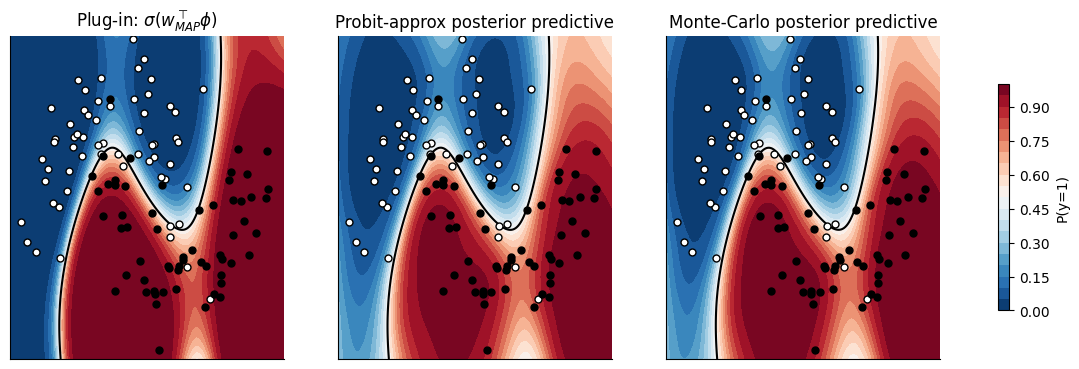

In [4]:
# Build grid for visualisation
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1.0, 1.5, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Phi_grid = featurise(grid)

p_probit = model.predict_proba(Phi_grid, method="probit").reshape(xx.shape)
p_mc = model.predict_proba_mc(Phi_grid, n_samples=3000, rng=rng).reshape(xx.shape)
# MAP-only ("plug-in")
p_map = expit(Phi_grid @ model.w_map).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, p, title in zip(
    axes,
    [p_map, p_probit, p_mc],
    ["Plug-in: $\\sigma(w_{MAP}^\\top \\phi)$",
     "Probit-approx posterior predictive",
     "Monte-Carlo posterior predictive"],
):
    cf = ax.contourf(xx, yy, p, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
    ax.contour(xx, yy, p, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X[y==0, 0], X[y==0, 1], c="white", edgecolor="k", s=25, zorder=3)
    ax.scatter(X[y==1, 0], X[y==1, 1], c="black", edgecolor="k", s=25, zorder=3)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(cf, ax=axes, shrink=0.7, label="P(y=1)")
plt.show()


In [5]:
# Numerical agreement between probit approx and MC
diff = np.abs(p_probit - p_mc).max()
print(f"Max abs difference probit vs MC: {diff:.4f}")
print(f"Mean abs difference            : {np.abs(p_probit - p_mc).mean():.4f}")


Max abs difference probit vs MC: 0.0235
Mean abs difference            : 0.0085


Observe:

- The plug-in classifier is over-confident near the decision boundary — its predicted probabilities drop off sharply from 0 to 1.
- The Bayesian predictive smooths this boundary out: predictions are pulled toward 0.5 in regions of weight uncertainty.
- This calibration effect is invisible from training accuracy alone, but crucial for downstream decisions (e.g.\ where to query for active learning).

## 5. Limitations of Laplace

Laplace is a **local** approximation. It captures the posterior near its mode and ignores everything else. Its main failure modes:

- **Multimodal posteriors.** Laplace centres on one mode and misses the others. Mixture-of-Laplace approximations help.
- **Skewed posteriors.** Laplace forces symmetry; for skewed posteriors (e.g.\ near boundaries) this can be a poor match. Variational methods (Week 4) and MCMC (Week 3) handle this directly.
- **High-dimensional posteriors with heavy tails.** The Gaussian's tails are too light; predictive intervals can be too narrow.

In the next two weeks we replace Laplace with sampling (MCMC) and optimisation-based approximations (VI) that lift these restrictions.

## 6. Exercises

**Exercise 2.9.** Derive the Hessian of the negative log posterior of Bayesian logistic regression. Show it is positive definite.

**Exercise 2.10 (Probit approx).** Verify Mackay's $\kappa(\sigma^2) = (1 + \pi \sigma^2 / 8)^{-1/2}$ numerically: compute $\int \sigma(a) \mathcal{N}(a \mid 0, \sigma^2) da$ via Gauss-Hermite quadrature and compare with $\sigma(0) = 0.5$ for various $\sigma$. Where does the approximation fail?

**Exercise 2.11 (Newton's method).** What happens if you initialise $w$ at a poor starting point? Implement IRLS — equivalent to Newton's method for this problem — and check convergence diagnostics.

**Exercise 2.12 (Active learning).** Use posterior variance over the decision boundary to drive an active-learning loop. On a synthetic 2D problem, compare query-by-uncertainty against random querying. Report accuracy as a function of labelled-set size.
